# Feature Selection


## Setup

Load the cleaned dataset and prepare features for selection methods.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, SelectFromModel, RFE, RFECV, SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

df = pd.read_csv("../Dataset/output1.csv")
df = df.drop(columns=["Unnamed: 0", "id"], errors="ignore")

for col in df.select_dtypes(include="object").columns:
    if col != "satisfaction":
        df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("satisfaction", axis=1)
y = LabelEncoder().fit_transform(df["satisfaction"])
feature_names = list(X.columns)
X_scaled = StandardScaler().fit_transform(X)

## <font color='pink'>**Feature Engineering**

In [3]:
df = pd.read_csv('output1.csv')
df.head()

,Unnamed: 0,id,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,...,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [4]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [5]:
df.columns

Index(['id', 'Gender', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class',
       'Flight_Distance', 'Inflight_wifi_service',
       'Departure/Arrival_time_convenient', 'Ease_of_Online_booking',
       'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort',
       'Inflight_entertainment', 'On-board_service', 'Leg_room_service',
       'Baggage_handling', 'Checkin_service', 'Inflight_service',
       'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes',
       'satisfaction'],
      dtype='object')

# Encoding Categorical Variables

In [6]:
def unique(C):
    for i in C:
        print(f"{i} ---> {df[i].unique()}")

In [7]:
d = df.columns

In [8]:
unique(d)

id ---> [ 70172   5047 110028 ...  37675  90086  34799]
Gender ---> ['Male' 'Female']
Customer_Type ---> ['Loyal Customer' 'disloyal Customer']
Age ---> [13 25 26 61 47 52 41 20 24 12 53 33 45 38  9 17 43 58 23 57 49 36 22 31
 15 35 67 37 40 34 39 50 29 54 21 28 27 69 60 48 59 46 30 66 64 44 51 32
 19 42 16 11 62  8 56 68 55 18 65 72 70 63 10  7 14 80 74 71 85 73 76 77
 75 79 78]
Type_of_Travel ---> ['Personal Travel' 'Business travel']
Class ---> ['Eco Plus' 'Business' 'Eco']
Flight_Distance ---> [ 460  235 1142 ... 1003 1441  884]
Inflight_wifi_service ---> [3 2 4 1 5 0]
Departure/Arrival_time_convenient ---> [4 2 5 3 1 0]
Ease_of_Online_booking ---> [3 2 5 4 1 0]
Gate_location ---> [1 3 2 5 4 0]
Food_and_drink ---> [5 1 2 4 3 0]
Online_boarding ---> [3 5 2 1 4 0]
Seat_comfort ---> [5 1 2 3 4 0]
Inflight_entertainment ---> [5 1 2 3 4 0]
On-board_service ---> [4 1 2 3 5 0]
Leg_room_service ---> [3 5 4 2 1 0]
Baggage_handling ---> [4 3 5 1 2]
Checkin_service ---> [4 1 3 5 2 0]
Inflight

In [9]:
from sklearn.preprocessing import LabelEncoder

def encode_dataframe(df):
    encoding_mapping = {}

    # Iterate over each column
    for column in df.columns:
        # Check if the column dtype is object (i.e., categorical)
        if df[column].dtype == 'object':
            # Create a LabelEncoder object
            label_encoder = LabelEncoder()
            # Fit and transform the column to obtain encoded values
            encoded_values = label_encoder.fit_transform(df[column])
            # Create a dictionary mapping original values to encoded values
            encoding_mapping[column] = dict(zip(df[column], encoded_values))
            # Replace the column values with encoded values
            df[column] = encoded_values
    
    return df, encoding_mapping

In [10]:
encoded_df, encoding_mapping = encode_dataframe(df)

encoded_df

,id,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,Ease_of_Online_booking,...,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
0,70172,1,0,13,1,2,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,0
1,5047,1,1,25,0,0,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,0
2,110028,0,0,26,0,0,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,24026,0,0,25,0,0,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,119299,1,0,61,0,0,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,78463,1,1,34,0,0,526,3,3,3,...,4,3,2,4,4,5,4,0,0.0,0
129876,71167,1,0,23,0,0,646,4,4,4,...,4,4,5,5,5,5,4,0,0.0,1
129877,37675,0,0,17,1,1,828,2,5,1,...,2,4,3,4,5,4,2,0,0.0,0
129878,90086,1,0,14,0,0,1127,3,3,3,...,4,3,2,5,4,5,4,0,0.0,1


In [11]:

# Print the encoding mapping
for column, mapping in encoding_mapping.items():
    print(f"Column: {column}")
    for original_value, encoded_value in mapping.items():
        print(f"{original_value} -> {encoded_value}")
    print()

Column: Gender
Male -> 1
Female -> 0

Column: Customer_Type
Loyal Customer -> 0
disloyal Customer -> 1

Column: Type_of_Travel
Personal Travel -> 1
Business travel -> 0

Column: Class
Eco Plus -> 2
Business -> 0
Eco -> 1

Column: satisfaction
neutral or dissatisfied -> 0
satisfied -> 1



In [12]:
df.head()

,id,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,Ease_of_Online_booking,...,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction
0,70172,1,0,13,1,2,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,0
1,5047,1,1,25,0,0,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,0
2,110028,0,0,26,0,0,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,24026,0,0,25,0,0,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,119299,1,0,61,0,0,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


### <font color='pink'>**Setting dependent and response variables for feature engineering**

In [13]:
X = df.loc[:, df.columns != 'satisfaction']
y = df['satisfaction']  # Select the target variable as a Series instead of a DataFrame

# <font color='gold'>**Top 10 feature selection through Chi-square**</font>

<h5>The Chi-Square test is a statistical test(univariate feature selection method) used to determine if there is a significant association between categorical variables. In feature selection, it measures the dependency between each feature and the target variable using the χ² statistic. It selects the k features with the highest χ² scores. This method is suitable for categorical features and a categorical target variable.</h5>

In [53]:
from sklearn.feature_selection import SelectKBest, chi2
X.columns

Index(['id', 'Gender', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class',
       'Flight_Distance', 'Inflight_wifi_service',
       'Departure/Arrival_time_convenient', 'Ease_of_Online_booking',
       'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort',
       'Inflight_entertainment', 'On-board_service', 'Leg_room_service',
       'Baggage_handling', 'Checkin_service', 'Inflight_service',
       'Cleanliness', 'Departure_Delay_in_Minutes',
       'Arrival_Delay_in_Minutes'],
      dtype='object')

In [57]:
categorical_features = X[[
        'Gender', 'Customer_Type','Type_of_Travel','Class', 'Inflight_wifi_service', 'Departure/Arrival_time_convenient', 'Ease_of_Online_booking','Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort',
       'Inflight_entertainment', 'On-board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness'
]].copy()
y_target_cat = y

In [60]:
selector = SelectKBest(chi2, k=10)
X_10_best = selector.fit_transform(categorical_features, y)

# Get the mask of selected features
selected_features_mask = selector.get_support()

# Get the names of selected features
chi_10_selected_features = categorical_features.columns[selected_features_mask]

print("The 10 most important features selected by chi-square test:")
print(chi_10_selected_features)

The 10 most important features selected by chi-square test:
Index(['Customer_Type', 'Type_of_Travel', 'Class', 'Inflight_wifi_service',
       'Online_boarding', 'Seat_comfort', 'Inflight_entertainment',
       'On-board_service', 'Leg_room_service', 'Cleanliness'],
      dtype='object')


The above are the top 10 features impacting on passenger satisfaction. We will check feature importance with other methods as well.

### <font color='yellow'>**Feature Importance using Wrapper Method(random forest)**</font>

<h5>The Wrapper Method involves training a machine learning model iteratively by considering different subsets of features. It evaluates the performance of the model with each subset of features and selects the subset that yields the best performance.</h5>

In [40]:
from sklearn.feature_selection import SelectFromModel


In [61]:

selector = SelectFromModel(rf(n_estimators=100, random_state=0))
selected_features = selector.fit_transform(X, y)
support = selector.get_support()
wrapper_features = X.loc[:, support].columns.tolist()
print(wrapper_features)

model = rf(n_estimators=100, random_state=0)
model.fit(X, y)
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
print(feature_importances)


['Type_of_Travel', 'Class', 'Inflight_wifi_service', 'Online_boarding', 'Seat_comfort', 'Inflight_entertainment']
id                                   0.029826
Gender                               0.003728
Customer_Type                        0.035108
Age                                  0.030020
Type_of_Travel                       0.099629
Class                                0.097405
Flight_Distance                      0.035487
Inflight_wifi_service                0.145169
Departure/Arrival_time_convenient    0.016849
Ease_of_Online_booking               0.034178
Gate_location                        0.015630
Food_and_drink                       0.010354
Online_boarding                      0.163768
Seat_comfort                         0.047860
Inflight_entertainment               0.053983
On-board_service                     0.033440
Leg_room_service                     0.033235
Baggage_handling                     0.021653
Checkin_service                      0.023300
Inflight_ser

In [111]:
s = feature_importances.sort_values(ascending=False)
sorted_features = s.keys()[:10]

In [112]:
s

Online_boarding                      0.163768
Inflight_wifi_service                0.145169
Type_of_Travel                       0.099629
Class                                0.097405
Inflight_entertainment               0.053983
Seat_comfort                         0.047860
Flight_Distance                      0.035487
Customer_Type                        0.035108
Ease_of_Online_booking               0.034178
On-board_service                     0.033440
Leg_room_service                     0.033235
Age                                  0.030020
id                                   0.029826
Cleanliness                          0.026593
Checkin_service                      0.023300
Inflight_service                     0.022528
Baggage_handling                     0.021653
Departure/Arrival_time_convenient    0.016849
Gate_location                        0.015630
Arrival_Delay_in_Minutes             0.010873
Food_and_drink                       0.010354
Departure_Delay_in_Minutes        

In [113]:
sorted_features

Index(['Online_boarding', 'Inflight_wifi_service', 'Type_of_Travel', 'Class',
       'Inflight_entertainment', 'Seat_comfort', 'Flight_Distance',
       'Customer_Type', 'Ease_of_Online_booking', 'On-board_service'],
      dtype='object')

In [46]:
wrapper_10_features = ['Online_boarding', 'Inflight_wifi_service', 'Type_of_Travel', 'Class',
       'Inflight_entertainment', 'Seat_comfort', 'Flight_Distance',
       'Customer_Type', 'Ease_of_Online_booking', 'On-board_service']

So only these six features are inherently important in contributing towards passenger satisfaction. However, we will again cross-check with another feature importance deciding method.

# Feature Permutation Importance


In [39]:
import warnings
warnings.filterwarnings("ignore")
import eli5
from eli5.sklearn import PermutationImportance

In [72]:
perm = PermutationImportance(rf(n_estimators=100, random_state=0).fit(X,y),random_state=1).fit(X,y)
eli5.show_weights(perm, feature_names = X.columns.tolist())

Weight,Feature
0.1466 ± 0.0008,Inflight_wifi_service
0.1350 ± 0.0016,Type_of_Travel
0.0532 ± 0.0006,Customer_Type
0.0411 ± 0.0011,Online_boarding
0.0339 ± 0.0005,Class
0.0259 ± 0.0004,Checkin_service
0.0186 ± 0.0005,Seat_comfort
0.0179 ± 0.0003,Baggage_handling
0.0158 ± 0.0002,Inflight_service
0.0151 ± 0.0006,Cleanliness


<h5>
So here is what just happened:<br>

- Weight: The weight represents the importance of each feature. It indicates how much the performance of the model decreases when the values of that feature are randomly permuted. The higher the weight, the more important the feature is for the model's predictions.

- Feature: The feature column lists the names of the features in your dataset.

- ±: The plus-minus symbol (±) indicates the standard deviation of the weight. It represents the variability in the feature importance when the permutation process is repeated multiple times. A larger standard deviation suggests that the feature's importance is less stable.

Now, let's analyze the result:

1. Inflight_wifi_service: This feature has the highest weight (0.1466) and is considered the most important feature according to Permutation Importance. It means that if you randomly permute the values of this feature, the model's performance would decrease significantly.

2. Type_of_Travel: This feature has the second-highest weight (0.1350). It is another important feature for the model's predictions.

3. Customer_Type: This feature has a weight of 0.0532, indicating its importance but to a lesser extent than the previous two features.

4. Online_boarding: This feature has a weight of 0.0411, suggesting it has some impact on the model's predictions.

5. Class: This feature has a weight of 0.0339, indicating its importance but to a lesser extent than the previous features.

The weights continue to decrease for the remaining features, indicating their decreasing importance.

The ± values associated with each weight represent the standard deviation of the feature's importance. For example, the weight for Inflight_wifi_service is given as 0.1466 ± 0.0008, which means that when the permutation process is repeated, the weight can vary within the range of (0.1466 - 0.0008) to (0.1466 + 0.0008). A smaller ± value suggests higher stability and consistency in the feature importance ranking.
</h5>

In [53]:
permutation_features = ['Inflight_wifi_service', 'Type_of_Travel', 'Customer_Type', 
                        'Online_boarding', 'Class', 'Checkin_service', 'Seat_comfort', 'Baggage_handling', 
                        'Inflight_service', 'Cleanliness']

From all above results, finally we can combine and conclude the list of important features.

<u>*Really Important Featurues*</u>: Type_of_Travel, Inflight_wifi_service, Online_boarding, Seat_comfort

<u>*Important Features*</u>: Class, Flight_Distance, Inflight_entertainment, On-board_service, Leg_room_service, Cleanliness, Checkin_service, Inflight_service, Baggage_handling

### <font color='violet'>**Feature Importance via Decision Tree**</font>


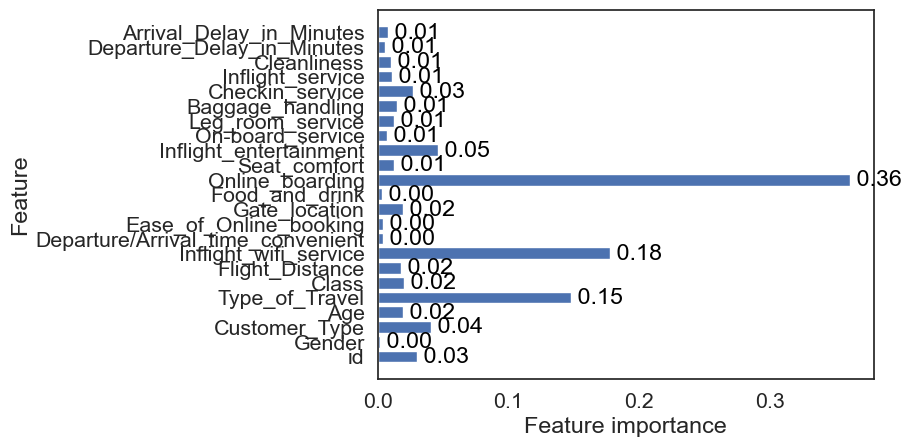

In [151]:
def plot_feature_importances_cancer(model, feature_names):
    n_features = len(feature_names)
    feature_importances = model.feature_importances_
    
    plt.barh(range(n_features), feature_importances, align='center')
    plt.yticks(np.arange(n_features), feature_names)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")

    for i, v in enumerate(feature_importances):
        plt.text(v, i, f" {v:.2f}", color='black', va='center')

# Assuming you have the following variables: tree, X_train_tree, y_train_tree, and df
tree = DecisionTreeClassifier(random_state=1)
tree.fit(X_train_tree, y_train_tree)

# Call the plot_feature_importances_cancer function
plot_feature_importances_cancer(tree, X.columns)
plt.show()


In [14]:
selected_dt = ["Online_boarding", "Inflight_wifi_service", "Type_of_Travel"]

### <font color='orange'>**Recursive Feature Elimination**</font>

<h5>
RFE is an iterative feature selection method that starts with all features and progressively eliminates the least important features based on their coefficients or importance scores.
It utilizes the logistic regression model to assess the importance of each feature and recursively prunes the least important features until the desired number of features is reached.
</h5>

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

In [154]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a logistic regression model
logreg = LogisticRegression(max_iter=1000)

# Apply Recursive Feature Elimination (RFE)
rfe = RFE(logreg, n_features_to_select=10)
rfe.fit(X_scaled, y)

selected_features_rfe = X.columns[rfe.support_].tolist()
selected_features_rfe

['Customer_Type',
 'Type_of_Travel',
 'Class',
 'Inflight_wifi_service',
 'Ease_of_Online_booking',
 'Online_boarding',
 'On-board_service',
 'Leg_room_service',
 'Checkin_service',
 'Cleanliness']

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression


In [33]:
def backward_selection(X, y, k_features=10):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    estimator = LogisticRegression()
    selector = RFE(estimator, n_features_to_select=k_features, step=1)
    selector = selector.fit(X_scaled, y)
    selected_features = X.columns[selector.support_].tolist()
    return selected_features

def forward_selection(X, y, k_features=10):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    estimator = LogisticRegression()
    selector = SequentialFeatureSelector(estimator, n_features_to_select=k_features, direction='forward')
    selector = selector.fit(X_scaled, y)
    selected_features = X.columns[selector.support_].tolist()
    return selected_features


In [34]:
backward_features = backward_selection(X, y, k_features=10)
forward_features = forward_selection(X, y, k_features=10)

In [38]:
forward_features

['Customer_Type',
 'Type_of_Travel',
 'Inflight_wifi_service',
 'Gate_location',
 'Online_boarding',
 'Inflight_entertainment',
 'On-board_service',
 'Leg_room_service',
 'Checkin_service',
 'Cleanliness']

In [44]:
from mlxtend.feature_selection import SequentialFeatureSelector

In [35]:

def stepwise_selection(X, y, k_features=10):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    estimator = LogisticRegression()
    selector = SequentialFeatureSelector(estimator, k_features=k_features, forward=True, floating=True, scoring='accuracy', cv=5)
    selector = selector.fit(X_scaled, y)
    selected_features = X.columns[list(selector.k_feature_idx_)].tolist()
    return selected_features

In [36]:
stepwise_features = stepwise_selection(X, y, k_features=10)

## **RFE via CV**

In [45]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [ ]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a logistic regression model
logreg = LogisticRegression(max_iter=1000)

# Perform Recursive Feature Elimination with Cross-Validation (RFE-CV)
rfe = RFECV(estimator=logreg)
rfe.fit(X_scaled, y)

# Get the selected features
selected_features_rfe = X.columns[rfe.support_].tolist()
print("Stepwise Selected Features (RFE-CV):", selected_features_rfe)

Stepwise Selected Features (RFE-CV): ['id', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class', 'Inflight_wifi_service', 'Departure/Arrival_time_convenient', 'Ease_of_Online_booking', 'Online_boarding', 'On-board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes']


In [46]:
from sklearn.ensemble import RandomForestClassifier as rf

#### <font color='red'>**Putting all the feature selection methods into a class for better code abstraction**</font>

In [ ]:
class FeatureSelections:
    def __init__(self):
        self.scaler = StandardScaler()
        self.estimator = LogisticRegression(max_iter=1000)
        self.model = rf(n_estimators=100, random_state=0)
    
    def chi_square(self, X, y, k=10):
        X_scaled = self.scaler.fit_transform(X)
        
        selector = SelectKBest(chi2, k=k)
        X_best = selector.fit_transform(X_scaled, y)
        selected_features_mask = selector.get_support()
        selected_features = X.columns[selected_features_mask]
        return selected_features
    
    def wrapper_method(self, X, y):
        X_scaled = self.scaler.fit_transform(X)
        
        selector = SelectFromModel(self.model)
        selector.fit_transform(X_scaled, y)
        support = selector.get_support()
        features = X.loc[:, support].columns.tolist()
        return features
    
    def permutation_method(self, X, y):
        model = rf(n_estimators=100, random_state=0).fit(X,y)
        perm = PermutationImportance(model, random_state=1).fit(X_scaled, y)
        weights = eli5.show_weights(perm, feature_names=X.columns.tolist())
        return weights
    
    def rfe(self, X, y, n_features_to_select=10):
        X_scaled = self.scaler.fit_transform(X)
        
        rfe = RFE(self.estimator, n_features_to_select=n_features_to_select)
        rfe.fit(X_scaled, y)
        selected_features = X.columns[rfe.support_].tolist()
        return selected_features
    
    def backward_selection(self, X, y, k_features=10):
        X_scaled = self.scaler.fit_transform(X)
        
        selector = RFE(self.estimator, n_features_to_select=k_features, step=1)
        selector = selector.fit(X_scaled, y)
        selected_features = X.columns[selector.support_].tolist()
        return selected_features
    
    def forward_selection(self, X, y, k_features=10):
        X_scaled = self.scaler.fit_transform(X)
        
        selector = SequentialFeatureSelector(self.estimator, n_features_to_select=k_features, direction='forward')
        selector = selector.fit(X_scaled, y)
        selected_features = X.columns[selector.support_].tolist()
        return selected_features
    
    def stepwise_selection(self, X, y, k_features=10):
        X_scaled = self.scaler.fit_transform(X)
        
        selector = SequentialFeatureSelector(self.estimator, k_features=k_features, forward=True, floating=True, scoring='accuracy', cv=5)
        selector = selector.fit(X_scaled, y)
        selected_features = X.columns[list(selector.k_feature_idx_)].tolist()
        return selected_features



In [ ]:
# Create an instance of the FeatureSelections class
fs = FeatureSelections()

# Perform chi-square feature selection
selected_features_chi2 = fs.chi_square(X, y, k=10)
print("Selected features (chi-square):", selected_features_chi2)

# Perform wrapper method feature selection
selected_features_wrapper = fs.wrapper_method(X, y)
print("Selected features (wrapper method):", selected_features_wrapper)

# Perform permutation feature importance method
permutation_results = fs.permutation_method(X, y)
print("Permutation feature importance results:\n", permutation_results)

# Perform Recursive Feature Elimination (RFE)
selected_features_rfe = fs.rfe(X, y, n_features_to_select=10)
print("Selected features (RFE):", selected_features_rfe)

# Perform backward selection
backward_features = fs.backward_selection(X, y, k_features=10)
print("Selected features (backward selection):", backward_features)

# Perform forward selection
forward_features = fs.forward_selection(X, y, k_features=10)
print("Selected features (forward selection):", forward_features)

# Perform stepwise selection
stepwise_features = fs.stepwise_selection(X, y, k_features=10)
print("Selected features (stepwise selection):", stepwise_features)


In [228]:
chi_sq = ['Customer_Type', 'Type_of_Travel', 'Class', 'Inflight_wifi_service',
       'Online_boarding', 'Seat_comfort', 'Inflight_entertainment',
       'On-board_service', 'Leg_room_service', 'Cleanliness']

decision_tree = ["Online_boarding", "Inflight_wifi_service", "Type_of_Travel"]

random_forest = ['Online_boarding', 'Inflight_wifi_service', 'Type_of_Travel', 'Class',
       'Inflight_entertainment', 'Seat_comfort', 'Flight_Distance',
       'Customer_Type', 'Ease_of_Online_booking', 'On-board_service']
permutation_features = ['Inflight_wifi_service', 'Type_of_Travel', 'Customer_Type', 
                        'Online_boarding', 'Class', 'Checkin_service', 'Seat_comfort', 'Baggage_handling', 
                        'Inflight_service', 'Cleanliness']

RFE = ['Customer_Type', 'Type_of_Travel','Class','Inflight_wifi_service','Ease_of_Online_booking','Online_boarding','On-board_service','Leg_room_service','Checkin_service','Cleanliness']
backward = backward_features 
forward = forward_features
stepwise = stepwise_features

In [230]:
lists_of_features_selected = [
    chi_sq, decision_tree, random_forest, permutation_features, RFE, backward, forward, stepwise
]

In [217]:
def find_intersection_and_union(list_of_lists):

    intersection = set(list_of_lists[0])
    for lst in list_of_lists[1:]:
        intersection = intersection.intersection(lst)
    intersection_list = list(intersection)

    union = set()
    for lst in list_of_lists:
        union = union.union(lst)
    union_list = list(union)

    return intersection_list, union_list

In [219]:
intersection, union = find_intersection_and_union(lists_of_features_selected)
print("Intersection:", intersection)
print("Union:", union)

Intersection: ['Type_of_Travel', 'Inflight_wifi_service', 'Online_boarding']
Union: ['Checkin_service', 'Cleanliness', 'Ease_of_Online_booking', 'Inflight_service', 'Online_boarding', 'Inflight_wifi_service', 'On-board_service', 'Gate_location', 'Customer_Type', 'Class', 'Inflight_entertainment', 'Flight_Distance', 'Baggage_handling', 'Leg_room_service', 'Type_of_Travel', 'Seat_comfort']


### <u>**Identifying confounding variables, colliders, and overdispersion**</u>

##### <font color='pink'>**Confounding variables**

<h5><b><u><font color='turquoise'>Our hypotheses</font></b></h5></u>

1. Age: Age may be associated with both the predictor variables (e.g., Gender, Type of Travel, Class) and customer satisfaction. For example, different age groups may have varying preferences or expectations when it comes to airline experiences.

2. Type of Travel: The purpose of travel (Personal or Business) may be associated with both the predictor variables (e.g., Gender, Class) and customer satisfaction. Business travelers, for instance, might have different satisfaction levels compared to personal travelers due to their specific needs and expectations.

3. Class: The class of travel (Eco Plus, Business, Eco) could be a confounding variable as it may be associated with both the predictor variables (e.g., Gender, Type of Travel) and customer satisfaction. Different classes may offer distinct services or amenities that can impact satisfaction levels.

#### <u>**1. Goal: Study the effect of age on customer satisfaction**

#### **Correlation Analysis**

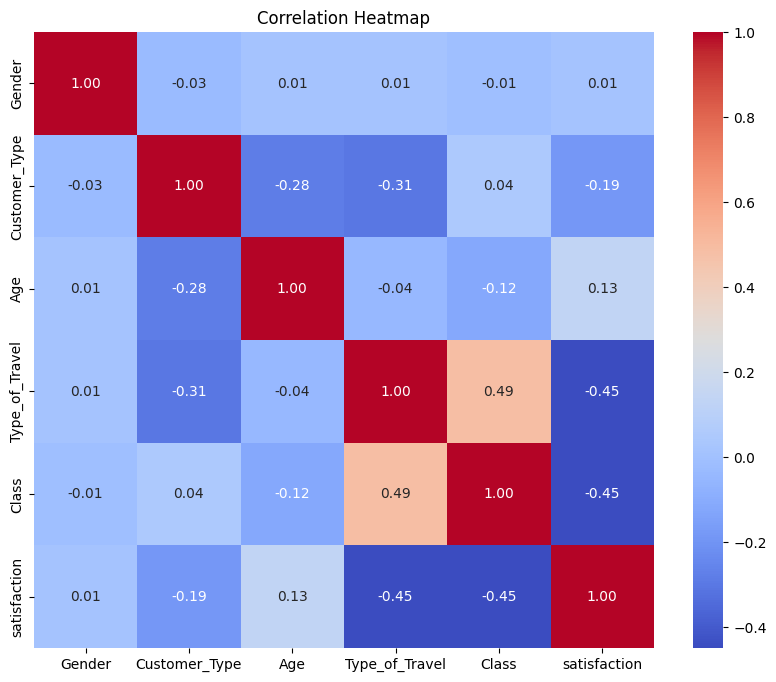

In [112]:
# Select the relevant columns from the dataframe
selected_columns = ['Gender', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class', 'satisfaction']
selected_data = df[selected_columns]

# Compute the correlation matrix
correlation_matrix = selected_data.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

#### **Multivariate Analysis**

In [158]:
# Prepare the data
X_1 = df[['Gender', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class', ]]
y_1 = df['satisfaction']

In [159]:
def is_confounder(A, b, var):
    # Add intercept to the predictors
    A = sm.add_constant(A)

    # Fit the logistic regression model with all predictor variables
    model_all = sm.Logit(b, A).fit()

    # Check the summary of the model
    print(model_all.summary())

    # Create a new dataset without the Age variable
    A_without_feature = A.drop(var, axis=1)

    # Fit the logistic regression model without the Age variable
    model_without_feature = sm.Logit(b, A_without_feature).fit()

    # Check the summary of the model without Age
    print(model_without_feature.summary())

    # Compare the coefficients
    coeff_all = model_all.params
    coeff_without_feature = model_without_feature.params

    # Check the change in coefficients
    coefficient_change = coeff_all - coeff_without_feature

    # Print the change in coefficients
    print(f"""
    Changes in coefficients:
    {coefficient_change}""")


In [160]:
D = {
    "Age": [X_1, y_1],
    "Type_of_Travel": [X_1, y_1],
    "Class": [X_1, y_1]
}

In [161]:
feat = list(D.keys())
feat

['Age', 'Type_of_Travel', 'Class']

In [162]:
for f in feat:
    print(f"Cofounder detection: {f}")
    is_confounder(X_1, y_1,f)

Cofounder detection: Age
Optimization terminated successfully.
         Current function value: 0.487258
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           satisfaction   No. Observations:               129880
Model:                          Logit   Df Residuals:                   129874
Method:                           MLE   Df Model:                            5
Date:                Tue, 23 May 2023   Pseudo R-squ.:                  0.2882
Time:                        15:12:15   Log-Likelihood:                -63285.
converged:                       True   LL-Null:                       -88907.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.2055      0.026     46.611      0.000       1.155     

### <font color='orange'><b>Confounder detection</b></font>

1. <font color='red'><b>Age</b></font>
   - Model with Age:
     - Coefficient estimate: -0.0005
     - P-value: 0.382

   - Model without Age:
     - Coefficient estimate: NaN (Not a Number)
     - P-value: N/A

   <b>Conclusion</b>: Based on the coefficient estimate and p-value, Age does not appear to be a confounder. Removing Age from the model does not significantly affect the coefficients of the other variables, indicating that it does not have a confounding effect on the relationship between the other variables and satisfaction.

2. <font color='red'><b>Type_of_Travel</b></font>
   - Model with Type_of_Travel:
     - Coefficient estimate: -2.4586
     - P-value: 0.000

   - Model without Type_of_Travel:
     - Coefficient estimate: NaN
     - P-value: N/A

  <b>Conclusion</b>: Type_of_Travel seems to be a confounder. The coefficient estimate for Type_of_Travel is significant in the model with all variables, but becomes NaN when Type_of_Travel is removed. This suggests that Type_of_Travel has a confounding effect on the relationship between the other variables and satisfaction.

3. <font color='red'><b>Class</b></font>
   - Model with Class:
     - Coefficient estimate: -0.9358
     - P-value: 0.000

   - Model without Class:
     - Coefficient estimate: NaN
     - P-value: N/A

   <b>Conclusion</b>: Class appears to be a confounder. The coefficient estimate for Class is significant in the model with all variables, but becomes NaN when Class is removed. This indicates that Class has a confounding effect on the relationship between the other variables and satisfaction.

<font color='gold'><b>Based on the analysis, Age is not a confounder, while both Type_of_Travel and Class can be considered confounders. Therefore, from now on, we will not include Age in our combined features and it's pretty logical that id should also not be in there.</b></font>

##### <font color='pink'>**Colliders**

In [83]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 129880 non-null  int64  
 1   Gender                             129880 non-null  int32  
 2   Customer_Type                      129880 non-null  int32  
 3   Age                                129880 non-null  int64  
 4   Type_of_Travel                     129880 non-null  int32  
 5   Class                              129880 non-null  int32  
 6   Flight_Distance                    129880 non-null  int64  
 7   Inflight_wifi_service              129880 non-null  int64  
 8   Departure/Arrival_time_convenient  129880 non-null  int64  
 9   Ease_of_Online_booking             129880 non-null  int64  
 10  Gate_location                      129880 non-null  int64  
 11  Food_and_drink                     1298

##### <font color='pink'>**Overdispersion**

##### <font color='pink'>**Collapsibility**

In [21]:
X.columns

Index(['id', 'Gender', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class',
       'Flight_Distance', 'Inflight_wifi_service',
       'Departure/Arrival_time_convenient', 'Ease_of_Online_booking',
       'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort',
       'Inflight_entertainment', 'On-board_service', 'Leg_room_service',
       'Baggage_handling', 'Checkin_service', 'Inflight_service',
       'Cleanliness', 'Departure_Delay_in_Minutes',
       'Arrival_Delay_in_Minutes'],
      dtype='object')

## <u><font color='turquoise'>**Dimensionality reduction**</font></u>

In [114]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

PCA's unsupervised algorithm assumed that all the variables are of the same scale, so if one variable is on a different scale then another, it will dominate the PCA procedure.

In [115]:
scaler_ = StandardScaler()

standardized_X = scaler_.fit_transform(X)

In [116]:
standardized_X

array([[ 0.13953224,  1.01487815, -0.47342178, ...,  1.30448651,
         0.27018709,  0.07690856],
       [-1.5974528 ,  1.01487815,  2.11228136, ..., -1.74040158,
        -0.36021434, -0.23545962],
       [ 1.20255375, -0.98533997, -0.47342178, ...,  1.30448651,
        -0.38648106, -0.39164371],
       ...,
       [-0.72721329, -0.98533997, -0.47342178, ..., -0.97917956,
        -0.38648106, -0.39164371],
       [ 0.6706696 ,  1.01487815, -0.47342178, ...,  0.54326449,
        -0.38648106, -0.39164371],
       [-0.80392069, -0.98533997, -0.47342178, ..., -1.74040158,
        -0.38648106, -0.39164371]])

In [117]:
pca_obj = PCA(10)

In [118]:
pca_obj.fit(standardized_X)

PCA(n_components=10)

In [119]:
B = pca_obj.transform(standardized_X)

In [120]:
B

array([[-1.26831112,  0.80204596,  0.41115793, ...,  0.53482682,
        -1.1350883 , -0.09225826],
       [ 3.14789033, -0.80932371, -1.5942083 , ...,  0.09192927,
        -0.61439148,  0.06164429],
       [-2.44220669,  1.88891286,  0.99261589, ..., -0.38745373,
         0.1862164 ,  0.14777967],
       ...,
       [ 2.02552794, -0.59767668, -1.95532333, ...,  0.06262676,
         1.45686492, -2.18548781],
       [-1.52113949,  0.30697589, -0.32806357, ...,  1.36837224,
        -0.56101749, -0.65755339],
       [ 4.36052003, -1.9287342 ,  2.24329876, ..., -0.01345721,
         1.7222234 , -0.06698603]])

In [121]:
explained_variance_ratio = pca_obj.explained_variance_ratio_
explained_variance_ratio

array([0.1771697 , 0.1036714 , 0.09619687, 0.08534864, 0.07764866,
       0.06536261, 0.04520356, 0.04417896, 0.04184641, 0.03859754])

In [124]:
type(explained_variance_ratio)


numpy.ndarray

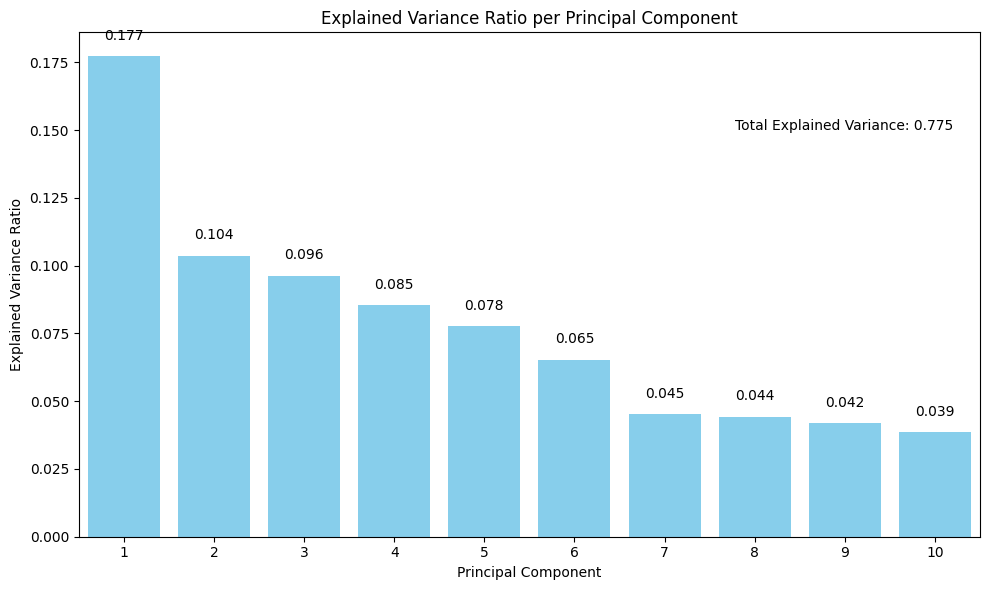

In [126]:
# Sort the explained variance ratio in descending order
sorted_variance_ratio = np.sort(explained_variance_ratio)[::-1]

# Create a larger figure
plt.figure(figsize=(10, 6))

# Create a bar chart
plt.bar(range(1, len(sorted_variance_ratio) + 1), sorted_variance_ratio, color='skyblue')

# Set the x-axis limits and ticks
plt.xlim(0.5, len(sorted_variance_ratio) + 0.5)
plt.xticks(range(1, len(sorted_variance_ratio) + 1))

# Add labels and title
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio per Principal Component')

# Add text annotations for each bar
for i, ratio in enumerate(sorted_variance_ratio):
    plt.text(i + 1, ratio + 0.005, f'{ratio:.3f}', ha='center', va='bottom')

# Calculate the total explained variance ratio
total_variance_ratio = np.sum(sorted_variance_ratio)

# Add a text box displaying the total explained variance ratio
text_box = f'Total Explained Variance: {total_variance_ratio:.3f}'
plt.text(len(sorted_variance_ratio) + 0.2, 0.15, text_box, ha='right')

# Show the plot
plt.tight_layout()
plt.show()


In [127]:
Projected_data = pca_obj.transform(standardized_X)

In [128]:
Projected_data.shape

(129880, 10)

### Below is the features we are concerned with

In [ ]:
f = ['Type_of_Travel','Inflight_wifi_service','Online_boarding','Seat_comfort','Flight_Distance',
            'Inflight_entertainment','On-board_service','Leg_room_service','Cleanliness','Checkin_service', 
            'Inflight_service', 'Baggage_handling', 'Class']